## 프로젝트 개요 및 환경 설정

### 라이브러리 설치 및 Import

In [65]:
# 데이터 처리 및 분석
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # maxOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'
    
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 시드 설정
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


### 데이터 로드

In [66]:
# 데이터 로드
df_transcript = pd.read_csv('../../Data/transcript.csv')
df_transcript.columns = df_transcript.columns.str.strip()

df_portfolio = pd.read_csv('../../Data/portfolio.csv')
df_portfolio.columns = df_portfolio.columns.str.strip()

df_profile = pd.read_csv('../../Data/profile.csv')
df_profile.columns = df_profile.columns.str.strip()

print("="*60)
print("데이터 로드 완료!")
print("="*60)

데이터 로드 완료!


## 데이터 이해

### 데이터 구조 파악

In [67]:
print("\n" + "="*60)
print("transcript 데이터")
print("="*60)
print(f"\ntranscript: {df_transcript.shape}")
print("\n[Data Info]")
df_transcript.info()


transcript 데이터

transcript: (306534, 5)

[Data Info]
<class 'pandas.DataFrame'>
RangeIndex: 306534 entries, 0 to 306533
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   Unnamed: 0  306534 non-null  int64
 1   person      306534 non-null  str  
 2   event       306534 non-null  str  
 3   value       306534 non-null  str  
 4   time        306534 non-null  int64
dtypes: int64(2), str(3)
memory usage: 11.7 MB


In [68]:
df_transcript.head()

,Unnamed: 0,person,event,value,time
0,0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0
1,1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0
2,2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0
3,3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0
4,4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0


In [69]:
print("\n" + "="*60)
print("portfolio 데이터")
print("="*60)
print(f"\nportfolio: {df_portfolio.shape}")
print("\n[Data Info]")
df_portfolio.info()


portfolio 데이터

portfolio: (10, 7)

[Data Info]
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  10 non-null     int64
 1   reward      10 non-null     int64
 2   channels    10 non-null     str  
 3   difficulty  10 non-null     int64
 4   duration    10 non-null     int64
 5   offer_type  10 non-null     str  
 6   id          10 non-null     str  
dtypes: int64(4), str(3)
memory usage: 692.0 bytes


In [70]:
df_portfolio.head()

,Unnamed: 0,reward,channels,difficulty,duration,offer_type,id
0,0,10,"['email', 'mobile', 'social']",10,7,bogo,ae264e3637204a6fb9bb56bc8210ddfd
1,1,10,"['web', 'email', 'mobile', 'social']",10,5,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0
2,2,0,"['web', 'email', 'mobile']",0,4,informational,3f207df678b143eea3cee63160fa8bed
3,3,5,"['web', 'email', 'mobile']",5,7,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9
4,4,5,"['web', 'email']",20,10,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7


In [71]:
print("\n" + "="*60)
print("profile 데이터")
print("="*60)
print(f"\nprofile: {df_profile.shape}")
print("\n[Data Info]")
df_profile.info()


profile 데이터

profile: (17000, 6)

[Data Info]
<class 'pandas.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        17000 non-null  int64  
 1   gender            14825 non-null  str    
 2   age               17000 non-null  int64  
 3   id                17000 non-null  str    
 4   became_member_on  17000 non-null  int64  
 5   income            14825 non-null  float64
dtypes: float64(1), int64(3), str(2)
memory usage: 797.0 KB


In [72]:
df_profile.head()

,Unnamed: 0,gender,age,id,became_member_on,income
0,0,NaN,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN
1,1,F,55,0610b486422d4921ae7d2bf64640c50b,20170715,112000.0
2,2,NaN,118,38fe809add3b4fcf9315a9694bb96ff5,20180712,NaN
3,3,F,75,78afa995795e4d85b5d9ceeca43f5fef,20170509,100000.0
4,4,NaN,118,a03223e636434f42ac4c3df47e8bac43,20170804,NaN


### 인덱스 컬럼 제거

In [73]:
df_transcript = df_transcript.drop(columns=['Unnamed: 0'])
df_portfolio = df_portfolio.drop(columns=['Unnamed: 0'])
df_profile = df_profile.drop(columns=['Unnamed: 0'])

print("="*60)
print("인덱스 컬럼 제거 완료!")
print("="*60)

인덱스 컬럼 제거 완료!


In [74]:
df_transcript.head()

,person,event,value,time
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0
1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0
2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0
4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0


### 컬럼별 의미 및 데이터 타입 확인

In [75]:
# =======================================================
# 스타벅스 주요 컬럼 설명
# =======================================================
# [transcript] 고객 행동 로그 테이블
# • person                        : 고객 ID (profile 데이터와 동일)
# • event                         : 기록 설명 (예: transaction, offer received, offer viewed 등)
#   - offer received: 고객이 프로모션을 받음
#   - offer viewed: 고객이 프로모션을 열람함
#   - offer completed: 고객이 프로모션 조건을 충족함
#   - transaction: 실제 결제가 발생함
# • value                         : (문자열 사전) - 레코드에 따라 제안 ID 또는 거래 금액 중 하나
# • time                          : 시간 (시 기준, t = 0 ~ 714 구간)
# =======================================================
# [portfolio] 프로모션 자체의 속성 테이블
# • reward                        : 제안 완료 시 지급되는 보상
# • channels                      : (문자열 목록) ['web', 'email', 'mobile', 'social']
# • difficulty                    : 제안 완료를 위한 최소 필요 금액
# • duration                      : 기간
# • offer_type                    : 제공 유형 (예: BOGO 1+1, 할인, 정보 제공)
# • id                            : 제안 ID
# =======================================================
# [profile] 고객 프로필 테이블
# • gender                        : 고객의 성별 (일부 항목에는 M 또는 F 대신 'O'가 포함되어 있을 수 있습니다.)
# • age                           : 고객의 연령
# • id                            : 고객 ID
# • became_member_on              : 고객이 앱 계정을 생성한 날짜
# • income                        : 고객의 소득

### 기초 통계량 확인

In [76]:
print("\n" + "="*60)
print("transcript 기초 통계")
print("="*60)
display(df_transcript.describe(include='all').T)


transcript 기초 통계


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
person,306534,17000,94de646f7b6041228ca7dec82adb97d2,51,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event,306534,4,transaction,138953,NaN,NaN,NaN,NaN,NaN,NaN,NaN
value,306534,5121,{'offer id': '2298d6c36e964ae4a3e7e9706d1fb8c2'},14983,NaN,NaN,NaN,NaN,NaN,NaN,NaN
time,306534.0,NaN,NaN,NaN,366.38294,200.326314,0.0,186.0,408.0,528.0,714.0


In [77]:
print("\n" + "="*60)
print("portfolio 기초 통계")
print("="*60)
display(df_portfolio.describe(include='all').T)


portfolio 기초 통계


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
reward,10.0,NaN,NaN,NaN,4.2,3.583915,0.0,2.0,4.0,5.0,10.0
channels,10,4,"['web', 'email', 'mobile', 'social']",4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
difficulty,10.0,NaN,NaN,NaN,7.7,5.831905,0.0,5.0,8.5,10.0,20.0
duration,10.0,NaN,NaN,NaN,6.5,2.321398,3.0,5.0,7.0,7.0,10.0
offer_type,10,3,bogo,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id,10,10,ae264e3637204a6fb9bb56bc8210ddfd,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [78]:
print("\n" + "="*60)
print("profile 기초 통계")
print("="*60)
display(df_profile.describe(include='all').T)


profile 기초 통계


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,14825,3,M,8484,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,17000.0,NaN,NaN,NaN,62.531412,26.73858,18.0,45.0,58.0,73.0,118.0
id,17000,17000,68be06ca386d4c31939f3a4f0e3dd783,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
became_member_on,17000.0,NaN,NaN,NaN,20167034.234118,11677.499961,20130729.0,20160526.0,20170802.0,20171230.0,20180726.0
income,14825.0,NaN,NaN,NaN,65404.991568,21598.29941,30000.0,49000.0,64000.0,80000.0,120000.0


### 고유값 확인

In [79]:
print("\n" + "="*60)
print("transcript 컬럼별 고유값 개수")
print("="*60)
print(df_transcript.nunique())


transcript 컬럼별 고유값 개수
person    17000
event         4
value      5121
time        120
dtype: int64


> person 컬럼이 외래키?

In [80]:
print("\n" + "="*60)
print("portfolio 컬럼별 고유값 개수")
print("="*60)
print(df_portfolio.nunique())


portfolio 컬럼별 고유값 개수
reward         5
channels       4
difficulty     5
duration       5
offer_type     3
id            10
dtype: int64


> id 컬럼이 기본키

In [81]:
print("\n" + "="*60)
print("profile 컬럼별 고유값 개수")
print("="*60)
print(df_profile.nunique())


profile 컬럼별 고유값 개수
gender                  3
age                    85
id                  17000
became_member_on     1716
income                 91
dtype: int64


> id 컬럼이 기본키
> gender 컬럼의 고유값이 3개 → M, F, O

In [82]:
df_profile['gender'].unique()

<StringArray>
[nan, 'F', 'M', 'O']
Length: 4, dtype: str

## 데이터 전처리

### 중복 데이터 확인

In [83]:
print("\n" + "="*60)
print("중복 데이터 확인")
print("="*60)

# 전체 행 중복 확인
print("\n[transcript 전체 행 기준 중복]")
print(f"행 중복: {df_transcript.duplicated().sum():,}건")

print("\n[portfolio 전체 행 기준 중복]")
print(f"행 중복: {df_portfolio.duplicated().sum():,}건")

print("\n[profile 전체 행 기준 중복]")
print(f"행 중복: {df_profile.duplicated().sum():,}건")


중복 데이터 확인

[transcript 전체 행 기준 중복]
행 중복: 397건

[portfolio 전체 행 기준 중복]
행 중복: 0건

[profile 전체 행 기준 중복]
행 중복: 0건


In [84]:
# transcript 중복 행 확인
dup_transcript = df_transcript[df_transcript.duplicated(keep=False)].copy()
dup_transcript = dup_transcript.sort_values(['person', 'event', 'value', 'time'])

print(dup_transcript.head(20))
print(f"중복 포함 전체 행 수: {dup_transcript.shape[0]:,}")
print(f"완전 중복으로 제거 대상 행 수: {df_transcript.duplicated().sum():,}")

                                  person            event  \
218058  00d7c95f793a4212af44e632fdc1e431  offer completed   
218060  00d7c95f793a4212af44e632fdc1e431  offer completed   
220133  01925607d99c460996c281f17cdbb9e2  offer completed   
220134  01925607d99c460996c281f17cdbb9e2  offer completed   
171646  01956670cf414b309675aa73368b94a9  offer completed   
171647  01956670cf414b309675aa73368b94a9  offer completed   
184896  01ff6c5d8d014dbd8c120e2b43a065ea  offer completed   
184897  01ff6c5d8d014dbd8c120e2b43a065ea  offer completed   
186623  0200f61c69da4c2ea078842cdaf234e6  offer completed   
186624  0200f61c69da4c2ea078842cdaf234e6  offer completed   
185391  0246f8fdf0b64014a98822b70231c58d  offer completed   
185392  0246f8fdf0b64014a98822b70231c58d  offer completed   
288574  034b962ed61d4da1bb0baaec84cc2e85  offer completed   
288575  034b962ed61d4da1bb0baaec84cc2e85  offer completed   
280283  03b326a99f5345df8b4d21ed26bdb0da  offer completed   
280284  03b326a99f5345df

> 로그 기록 시에 person, event, value, time이 완전히 동일한 중복 기록된 데이터 있는 것으로 판단  
> → 2개 or 3개 이상 중복 기록된 행 존재  
> → 1개 행만 남기고 중복 행 제거

In [85]:
# transcript 중복 데이터 처리
print("="*60)
print("중복 제거 전")
print("="*60)
print(df_transcript.shape)

df_transcript = df_transcript.drop_duplicates().reset_index(drop=True)

print("\n" + "="*60)
print("중복 제거 후")
print("="*60)
print(df_transcript.shape)
print(f"남은 중복 수: {df_transcript.duplicated().sum():,}건")

중복 제거 전
(306534, 4)

중복 제거 후
(306137, 4)
남은 중복 수: 0건


> 306534건 → 306137건 : 397건 제거 완료

### 결측치 확인

In [86]:
# transcript 결측치 확인
print("\n" + "="*60)
print("transcript 결측치 확인")
print("="*60)

missing_df_transcript = pd.DataFrame({
    '결측수': df_transcript.isnull().sum(),
    '결측비율(%)': (df_transcript.isnull().sum() / len(df_transcript) * 100).round(2)
})
missing_df_transcript = missing_df_transcript[missing_df_transcript['결측수'] > 0].sort_values('결측수', ascending=False)

if len(missing_df_transcript) > 0:
    print("\n[결측치 현황]")
    display(missing_df_transcript)
else:
    print("\n결측치 없음")



transcript 결측치 확인

결측치 없음


In [87]:
# portfolio 결측치 확인
print("\n" + "="*60)
print("portfoilo 결측치 확인")
print("="*60)

missing_df_portfolio = pd.DataFrame({
    '결측수': df_portfolio.isnull().sum(),
    '결측비율(%)': (df_portfolio.isnull().sum() / len(df_portfolio) * 100).round(2)
})
missing_df_portfolio = missing_df_portfolio[missing_df_portfolio['결측수'] > 0].sort_values('결측수', ascending=False)

if len(missing_df_portfolio) > 0:
    print("\n[결측치 현황]")
    display(missing_df_portfolio)
else:
    print("\n결측치 없음")



portfoilo 결측치 확인

결측치 없음


In [88]:
# profile 결측치 확인
print("\n" + "="*60)
print("profile 결측치 확인")
print("="*60)

missing_df_profile = pd.DataFrame({
    '결측수': df_profile.isnull().sum(),
    '결측비율(%)': (df_profile.isnull().sum() / len(df_profile) * 100).round(2)
})
missing_df_profile = missing_df_profile[missing_df_profile['결측수'] > 0].sort_values('결측수', ascending=False)

if len(missing_df_profile) > 0:
    print("\n[결측치 현황]")
    display(missing_df_profile)
else:
    print("\n결측치 없음")



profile 결측치 확인

[결측치 현황]


,결측수,결측비율(%)
gender,2175,12.79
income,2175,12.79


In [89]:
# 2175건 모두 gender & income 컬럼 동시에 비어있는지 확인
print((df_profile['gender'].isnull() & df_profile['income'].isnull()).sum())

2175


> 2175 모두 gender & income 컬럼 동시에 비어 있음  
> → 고객 정보 수집이 안된 행 : 2175건

> 이 결측치들을 Drop?  
> 평균이나 중앙값으로 하면 경향이 왜곡될 수 있음  
> 우선 그대로 놔두되, income_missing 컬럼 만들어 관리

In [90]:
# income_missing 파생 컬럼 생성
df_profile['income_missing'] = df_profile['income'].isnull().astype(int)

In [91]:
# gender 고유값 확인
df_profile['gender'].unique()

<StringArray>
[nan, 'F', 'M', 'O']
Length: 4, dtype: str

In [92]:
# gender 결측치를 Unknown으로 지정
df_profile['gender'] = df_profile['gender'].fillna('Unknown')

In [93]:
# gender 고유값 재확인: Unknown 적용 됐는지
df_profile['gender'].unique()

<StringArray>
['Unknown', 'F', 'M', 'O']
Length: 4, dtype: str

> gender 컬럼의 결측치는 'F', 'M', 'O'와 구분되도록 'Unknown' 값으로 넣어줌  
> 'O'의 경우가 애매하지만, 실제 정보 기입한 고객과 분리가 필요할 것 같음

In [94]:
# profile 결측치 재확인
df_profile.isnull().sum()

gender                 0
age                    0
id                     0
became_member_on       0
income              2175
income_missing         0
dtype: int64

### 데이터 타입 변환

#### transcript 테이블

In [95]:
df_transcript.info()

<class 'pandas.DataFrame'>
RangeIndex: 306137 entries, 0 to 306136
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   person  306137 non-null  str  
 1   event   306137 non-null  str  
 2   value   306137 non-null  str  
 3   time    306137 non-null  int64
dtypes: int64(1), str(3)
memory usage: 9.3 MB


In [96]:
df_transcript['event'].unique()

<StringArray>
['offer received', 'offer viewed', 'transaction', 'offer completed']
Length: 4, dtype: str

In [97]:
# event 컬럼 범주형 변환
df_transcript['event'] = df_transcript['event'].astype('category')

In [98]:
df_transcript.info()

<class 'pandas.DataFrame'>
RangeIndex: 306137 entries, 0 to 306136
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype   
---  ------  --------------   -----   
 0   person  306137 non-null  str     
 1   event   306137 non-null  category
 2   value   306137 non-null  str     
 3   time    306137 non-null  int64   
dtypes: category(1), int64(1), str(2)
memory usage: 7.3 MB


#### portfolio 테이블

In [99]:
df_portfolio.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   reward      10 non-null     int64
 1   channels    10 non-null     str  
 2   difficulty  10 non-null     int64
 3   duration    10 non-null     int64
 4   offer_type  10 non-null     str  
 5   id          10 non-null     str  
dtypes: int64(3), str(3)
memory usage: 612.0 bytes


In [100]:
df_portfolio['channels'].unique()

<StringArray>
[       '['email', 'mobile', 'social']',
 '['web', 'email', 'mobile', 'social']',
           '['web', 'email', 'mobile']',
                     '['web', 'email']']
Length: 4, dtype: str

> 리스트로 조합이 되어 있어서 범주형으로 바꾸기 애매함  
> 파생 컬럼 만들어서 관리해야 할 듯

In [101]:
df_portfolio['offer_type'].unique()

<StringArray>
['bogo', 'informational', 'discount']
Length: 3, dtype: str

In [102]:
# offer_type 컬럼 범주형 변환
df_portfolio['offer_type'] = df_portfolio['offer_type'].astype('category')

In [103]:
df_portfolio.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   reward      10 non-null     int64   
 1   channels    10 non-null     str     
 2   difficulty  10 non-null     int64   
 3   duration    10 non-null     int64   
 4   offer_type  10 non-null     category
 5   id          10 non-null     str     
dtypes: category(1), int64(3), str(2)
memory usage: 566.0 bytes


#### profile 테이블

In [104]:
df_profile.info()

<class 'pandas.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            17000 non-null  str    
 1   age               17000 non-null  int64  
 2   id                17000 non-null  str    
 3   became_member_on  17000 non-null  int64  
 4   income            14825 non-null  float64
 5   income_missing    17000 non-null  int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 797.0 KB


> profile 테이블에서 became_member_on 컬럼 값이 날짜임에도 int 형식으로 되어 있음  
> → date 타입으로 변환 필요

In [105]:
df_profile['became_member_on'].head()

0    20170212
1    20170715
2    20180712
3    20170509
4    20170804
Name: became_member_on, dtype: int64

In [106]:
# became_member_on 컬럼 데이터 형식 변환
df_profile['became_member_on'] = pd.to_datetime(df_profile['became_member_on'].astype(str), format='%Y%m%d')

In [107]:
df_profile.info()

<class 'pandas.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   gender            17000 non-null  str           
 1   age               17000 non-null  int64         
 2   id                17000 non-null  str           
 3   became_member_on  17000 non-null  datetime64[us]
 4   income            14825 non-null  float64       
 5   income_missing    17000 non-null  int64         
dtypes: datetime64[us](1), float64(1), int64(2), str(2)
memory usage: 797.0 KB


In [108]:
df_profile['became_member_on'].head()

0   2017-02-12
1   2017-07-15
2   2018-07-12
3   2017-05-09
4   2017-08-04
Name: became_member_on, dtype: datetime64[us]

In [109]:
# gender 컬럼 범주형 변환
df_profile['gender'] = df_profile['gender'].astype('category')

In [110]:
df_profile.info()

<class 'pandas.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   gender            17000 non-null  category      
 1   age               17000 non-null  int64         
 2   id                17000 non-null  str           
 3   became_member_on  17000 non-null  datetime64[us]
 4   income            14825 non-null  float64       
 5   income_missing    17000 non-null  int64         
dtypes: category(1), datetime64[us](1), float64(1), int64(2), str(1)
memory usage: 680.8 KB


### 이상치 처리

In [111]:
df_transcript.describe()

,time
count,306137.000000
mean,366.185015
std,200.348174
min,0.000000
25%,186.000000
50%,408.000000
75%,528.000000
max,714.000000


In [112]:
df_portfolio.describe()

,reward,difficulty,duration
count,10.000000,10.000000,10.000000
mean,4.200000,7.700000,6.500000
std,3.583915,5.831905,2.321398
min,0.000000,0.000000,3.000000
25%,2.000000,5.000000,5.000000
50%,4.000000,8.500000,7.000000
75%,5.000000,10.000000,7.000000
max,10.000000,20.000000,10.000000


In [113]:
df_profile.describe()

,age,became_member_on,income,income_missing
count,17000.000000,17000,14825.000000,17000.000000
mean,62.531412,2017-02-23 13:12:10.164706,65404.991568,0.127941
min,18.000000,2013-07-29 00:00:00,30000.000000,0.000000
25%,45.000000,2016-05-26 00:00:00,49000.000000,0.000000
50%,58.000000,2017-08-02 00:00:00,64000.000000,0.000000
75%,73.000000,2017-12-30 00:00:00,80000.000000,0.000000
max,118.000000,2018-07-26 00:00:00,120000.000000,1.000000
std,26.738580,NaN,21598.299410,0.334034


> age 컬럼 max 값이 118 → 이상치 처리?

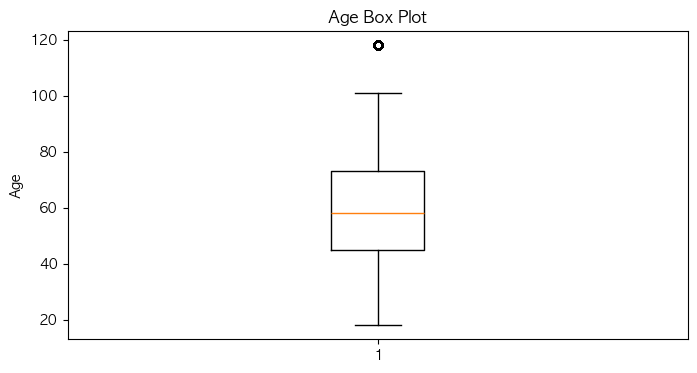

In [114]:
plt.figure(figsize=(8, 4))
plt.boxplot(df_profile['age'])
plt.title('Age Box Plot')
plt.ylabel('Age')
plt.show()

> Box Plot 확인 결과 age == 118 이 이상치로 두껍게 표시되어 있음  
> 실제 고객 나이가 118살이 아니라 별도 이상치 처리 해놨을 가능성 O

In [115]:
# age == 118인 데이터 수 확인
print((df_profile['age'] == 118).sum())

2175


> 앞에서 gender와 income 값이 없었던 2175건과 동일  
> 2175건이 고객 데이터 누락 행?

In [116]:
df_profile[df_profile['age'] == 118][['gender', 'income', 'income_missing']].head()

,gender,income,income_missing
0,Unknown,NaN,1
2,Unknown,NaN,1
4,Unknown,NaN,1
6,Unknown,NaN,1
7,Unknown,NaN,1


In [117]:
df_profile[df_profile['age'] == 118]['income'].isnull().sum()

np.int64(2175)

> age == 118인 값들을 결측치로 모두 바꾸고, age_missing 컬럼 생성해서 별도 관리

In [118]:
# income과 마찬가지로 age 값을 결측치로 놔두기
df_profile['age'] = df_profile['age'].replace(118, np.nan)
df_profile['age_missing'] = df_profile['age'].isna().astype(int)

In [119]:
df_profile.info()

<class 'pandas.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   gender            17000 non-null  category      
 1   age               14825 non-null  float64       
 2   id                17000 non-null  str           
 3   became_member_on  17000 non-null  datetime64[us]
 4   income            14825 non-null  float64       
 5   income_missing    17000 non-null  int64         
 6   age_missing       17000 non-null  int64         
dtypes: category(1), datetime64[us](1), float64(2), int64(2), str(1)
memory usage: 813.6 KB


In [120]:
df_profile.isna().sum()

gender                 0
age                 2175
id                     0
became_member_on       0
income              2175
income_missing         0
age_missing            0
dtype: int64

### 딕셔너리 & 리스트 형태 분리

#### transcript

In [121]:
# value 컬럼
# {'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'}
# {'amount': 21.35}
# {'offer_id': 'fafdcd668e3743c1bb461111dcafc2a4', 'reward': 2}

In [122]:
# # 공통적으로 '}' 와 "'" 를 제거
# clean_value = df_transcript['value'].str.replace(r"[\{\}']", "", regex=True)

# # ':' 를 기준으로 나누고 마지막 값을 가져옴
# # 'offer'가 포함된 행은 offer_id로, 'amount'가 포함된 행은 amount로 나눠줌
# if len(df_transcript['value']) == 2:
#     df_transcript['offer_id'] = clean_value[0].str.split(':').str[-1].str.strip()
#     df_transcript['reward'] = clean_value[1].str.split(':').str[-1].str.strip()
# else: 
#     df_transcript['offer_id'] = clean_value.str.split(':').str[-1].str.strip()
#     df_transcript.loc[~df_transcript['value'].str.contains('offer'), 'offer_id'] = None

# df_transcript['amount'] = clean_value.str.split(':').str[-1].str.strip()
# df_transcript.loc[~df_transcript['value'].str.contains('amount'), 'amount'] = None
# df_transcript['amount'] = pd.to_numeric(df_transcript['amount'])

# # 결과 확인
# print(df_transcript[['event', 'offer_id', 'amount']].tail(10))

In [123]:
# df_transcript['offer_id'] = df_transcript['value'].str.extract(r"'offer[_ ]id':\s*'([^']+)'")
# df_transcript['amount'] = df_transcript['value'].str.extract(r"'amount':\s*([0-9.]+)")
# df_transcript['reward'] = df_transcript['value'].str.extract(r"'reward':\s*([0-9.]+)")

# df_transcript['amount'] = pd.to_numeric(df_transcript['amount'], errors='coerce')
# df_transcript['reward'] = pd.to_numeric(df_transcript['reward'], errors='coerce')

In [124]:
import ast
import pandas as pd

# 1. value 문자열 -> dict 변환
df_transcript['value_dict'] = df_transcript['value'].apply(ast.literal_eval)

# 2. 필요한 값 추출
df_transcript['offer_id'] = df_transcript['value_dict'].apply(
    lambda x: x.get('offer id') if 'offer id' in x else x.get('offer_id')
)
df_transcript['amount'] = df_transcript['value_dict'].apply(lambda x: x.get('amount'))
df_transcript['reward'] = df_transcript['value_dict'].apply(lambda x: x.get('reward'))

# 3. 숫자형 변환
df_transcript['amount'] = pd.to_numeric(df_transcript['amount'], errors='coerce')
df_transcript['reward'] = pd.to_numeric(df_transcript['reward'], errors='coerce').astype('Int64')

# 4. 결과 확인
print(df_transcript[['event', 'offer_id', 'amount', 'reward']].tail(10))

                  event                          offer_id  amount  reward
306127      transaction                               NaN   25.14    <NA>
306128      transaction                               NaN   43.58    <NA>
306129      transaction                               NaN   22.64    <NA>
306130  offer completed  fafdcd668e3743c1bb461111dcafc2a4     NaN       2
306131      transaction                               NaN    2.20    <NA>
306132      transaction                               NaN    1.59    <NA>
306133      transaction                               NaN    9.53    <NA>
306134      transaction                               NaN    3.61    <NA>
306135      transaction                               NaN    3.53    <NA>
306136      transaction                               NaN    4.05    <NA>


In [125]:
df_transcript.info()

<class 'pandas.DataFrame'>
RangeIndex: 306137 entries, 0 to 306136
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   person      306137 non-null  str     
 1   event       306137 non-null  category
 2   value       306137 non-null  str     
 3   time        306137 non-null  int64   
 4   value_dict  306137 non-null  object  
 5   offer_id    167184 non-null  str     
 6   amount      138953 non-null  float64 
 7   reward      33182 non-null   Int64   
dtypes: Int64(1), category(1), float64(1), int64(1), object(1), str(3)
memory usage: 16.9+ MB


In [126]:
# 결과 확인
print(df_transcript[['event', 'offer_id', 'amount']].head(10))

            event                          offer_id  amount
0  offer received  9b98b8c7a33c4b65b9aebfe6a799e6d9     NaN
1  offer received  0b1e1539f2cc45b7b9fa7c272da2e1d7     NaN
2  offer received  2906b810c7d4411798c6938adc9daaa5     NaN
3  offer received  fafdcd668e3743c1bb461111dcafc2a4     NaN
4  offer received  4d5c57ea9a6940dd891ad53e9dbe8da0     NaN
5  offer received  f19421c1d4aa40978ebb69ca19b0e20d     NaN
6  offer received  2298d6c36e964ae4a3e7e9706d1fb8c2     NaN
7  offer received  3f207df678b143eea3cee63160fa8bed     NaN
8  offer received  0b1e1539f2cc45b7b9fa7c272da2e1d7     NaN
9  offer received  0b1e1539f2cc45b7b9fa7c272da2e1d7     NaN


In [127]:
df_portfolio['channels'].unique()

<StringArray>
[       '['email', 'mobile', 'social']',
 '['web', 'email', 'mobile', 'social']',
           '['web', 'email', 'mobile']',
                     '['web', 'email']']
Length: 4, dtype: str

#### offer_type & id 병합 파생컬럼

In [129]:
df_portfolio['offer_type'].unique()

['bogo', 'informational', 'discount']
Categories (3, str): ['bogo', 'discount', 'informational']

In [130]:
# offer_label = offer_type + '_' + 순서
# ex) bogo_1, informational_1, discount_1
df_portfolio['offer_label'] = (
    df_portfolio['offer_type'].astype(str)
    + '_'
    + (df_portfolio.groupby('offer_type').cumcount() + 1).astype(str)
)

df_portfolio['offer_label'].unique()

<StringArray>
[         'bogo_1',          'bogo_2', 'informational_1',          'bogo_3',
      'discount_1',      'discount_2',      'discount_3', 'informational_2',
          'bogo_4',      'discount_4']
Length: 10, dtype: str

In [134]:
df_transcript['time_days'] = df_transcript['time'] / 24
df_transcript.info()

<class 'pandas.DataFrame'>
RangeIndex: 306137 entries, 0 to 306136
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   person      306137 non-null  str     
 1   event       306137 non-null  category
 2   value       306137 non-null  str     
 3   time        306137 non-null  int64   
 4   value_dict  306137 non-null  object  
 5   offer_id    167184 non-null  str     
 6   amount      138953 non-null  float64 
 7   reward      33182 non-null   Int64   
 8   time_days   306137 non-null  float64 
dtypes: Int64(1), category(1), float64(2), int64(1), object(1), str(3)
memory usage: 19.3+ MB
